In [4]:
# 0) Imports & settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_PATH = "house_price_data_worldwide.csv"  # change if needed


In [5]:
# 1) Load data
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (500, 7)


,Country,State/Region,City,Square Footage (SqFt),Bedrooms,Population Density (people per sq km),Price of House
0,India,Maharashtra,Mumbai,2753,2,7414,655861.13
1,Canada,Quebec,Laval,4967,1,19449,2431715.11
2,USA,California,Los Angeles,2405,5,19826,387589.11
3,Germany,North Rhine-Westphalia,City,2305,4,19409,886424.62
4,Brazil,Sao Paulo,Sao Paulo City,3962,3,9205,999018.80


In [6]:
# 2) Standardize columns and types
def normalize_col(c: str) -> str:
    c = str(c).replace("\u00a0", " ")          # non-breaking space
    c = re.sub(r"\s+", " ", c).strip().lower()
    c = c.replace(" ", "_")
    return c

df = df_raw.copy()
df.columns = [normalize_col(c) for c in df.columns]

print("Normalized columns:", list(df.columns))

# Explicit mapping based on this dataset
COL_COUNTRY = "country"
COL_REGION  = "state/region" if "state/region" in df.columns else None
COL_CITY    = "city"
COL_SQFT    = "square_footage_(sqft)"
COL_PRICE   = "price_of_house"
COL_BEDS    = "bedrooms"
COL_POPDEN  = "population_density_(people_per_sq_km)"

# Coerce numerics (handles strings w/ commas/currency if present)
def to_numeric_clean(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(r"[^\d\.\-]", "", regex=True), errors="coerce")

for c in [COL_SQFT, COL_PRICE, COL_BEDS, COL_POPDEN]:
    if c in df.columns:
        df[c] = to_numeric_clean(df[c])

df.info()


Normalized columns: ['country', 'state/region', 'city', 'square_footage_(sqft)', 'bedrooms', 'population_density_(people_per_sq_km)', 'price_of_house']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   country                                500 non-null    object 
 1   state/region                           500 non-null    object 
 2   city                                   500 non-null    object 
 3   square_footage_(sqft)                  500 non-null    int64  
 4   bedrooms                               500 non-null    int64  
 5   population_density_(people_per_sq_km)  500 non-null    int64  
 6   price_of_house                         500 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 27.5+ KB


In [7]:
# 3) Data quality quick checks: missingness
missing = df.isna().mean().sort_values(ascending=False)
missing_df = (missing * 100).to_frame("missing_%")
missing_df[missing_df["missing_%"] > 0].head(20)


,missing_%


In [8]:
# Visual: missingness (top 10)
top_missing = missing_df[missing_df["missing_%"] > 0].head(10)
if len(top_missing) == 0:
    print("No missing values detected.")
else:
    plt.figure(figsize=(10, 4))
    plt.bar(top_missing.index, top_missing["missing_%"])
    plt.title("Missing Values (%) — Top Columns")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing (%)")
    plt.show()


No missing values detected.


In [9]:
# Basic numeric summary
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
square_footage_(sqft),500.0,2.760734e+03,1.261906e+03,529.00,1670.00,2765.500,3.885500e+03,4999.00
bedrooms,500.0,3.556000e+00,1.757567e+00,1.00,2.00,4.000,5.000000e+00,6.00
population_density_(people_per_sq_km),500.0,1.049648e+04,5.533758e+03,272.00,5797.00,10784.000,1.531975e+04,19923.00
price_of_house,500.0,1.534485e+06,1.014002e+06,140754.22,707451.83,1229617.155,2.165636e+06,4763566.21


In [10]:
# 4) Cleaning & feature engineering
df = df.dropna(subset=[COL_PRICE, COL_SQFT]).copy()
df = df[(df[COL_PRICE] > 0) & (df[COL_SQFT] > 0)].copy()

SQFT_TO_SQM = 0.092903
df["living_area_sqm"] = df[COL_SQFT] * SQFT_TO_SQM
df["price_per_sqm"] = df[COL_PRICE] / df["living_area_sqm"]

# log transforms
df["log_price"] = np.log10(df[COL_PRICE])
df["log_price_per_sqm"] = np.log10(df["price_per_sqm"])

# tiers
q33, q66 = df[COL_PRICE].quantile([0.33, 0.66])
df["tier"] = pd.cut(
    df[COL_PRICE],
    [-np.inf, q33, q66, np.inf],
    labels=["Affordable", "Mid-Range", "Luxury"]
)

print("Rows after cleaning:", df.shape[0])
df.head()


Rows after cleaning: 500


,country,state/region,city,square_footage_(sqft),bedrooms,population_density_(people_per_sq_km),price_of_house,living_area_sqm,price_per_sqm,log_price,log_price_per_sqm,tier
0,India,Maharashtra,Mumbai,2753,2,7414,655861.13,255.761959,2564.341986,5.816812,3.408976,Affordable
1,Canada,Quebec,Laval,4967,1,19449,2431715.11,461.449201,5269.735227,6.385913,3.721789,Luxury
2,USA,California,Los Angeles,2405,5,19826,387589.11,223.431715,1734.709461,5.588372,3.239227,Affordable
3,Germany,North Rhine-Westphalia,City,2305,4,19409,886424.62,214.141415,4139.435709,5.947642,3.616941,Mid-Range
4,Brazil,Sao Paulo,Sao Paulo City,3962,3,9205,999018.80,368.081686,2714.122539,5.999574,3.433629,Mid-Range


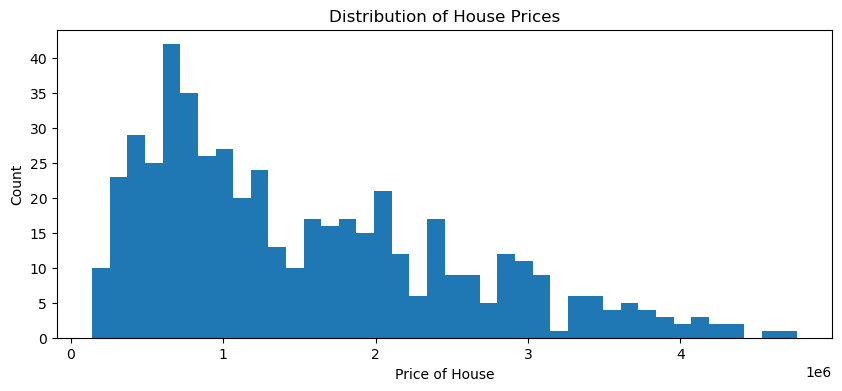

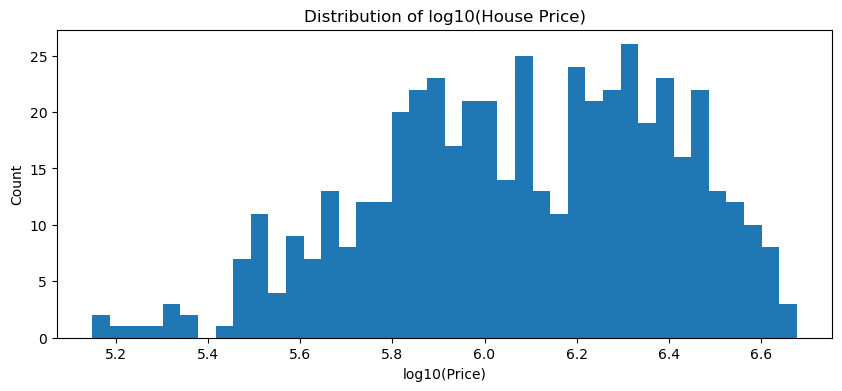

In [11]:
# 5) Univariate: price distributions
plt.figure(figsize=(10, 4))
plt.hist(df[COL_PRICE], bins=40)
plt.title("Distribution of House Prices")
plt.xlabel("Price of House")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df["log_price"], bins=40)
plt.title("Distribution of log10(House Price)")
plt.xlabel("log10(Price)")
plt.ylabel("Count")
plt.show()


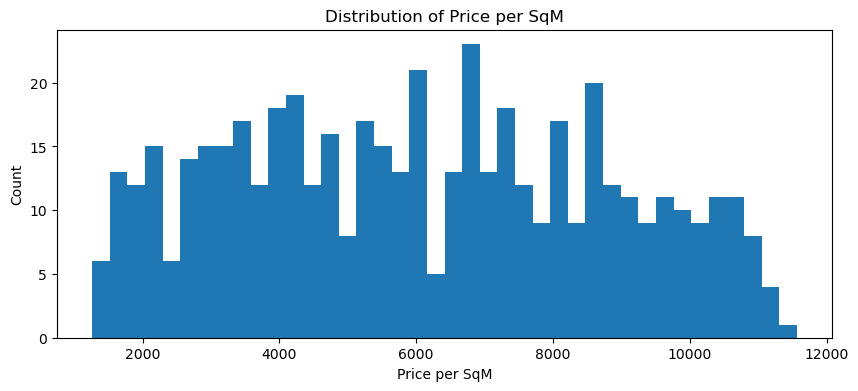

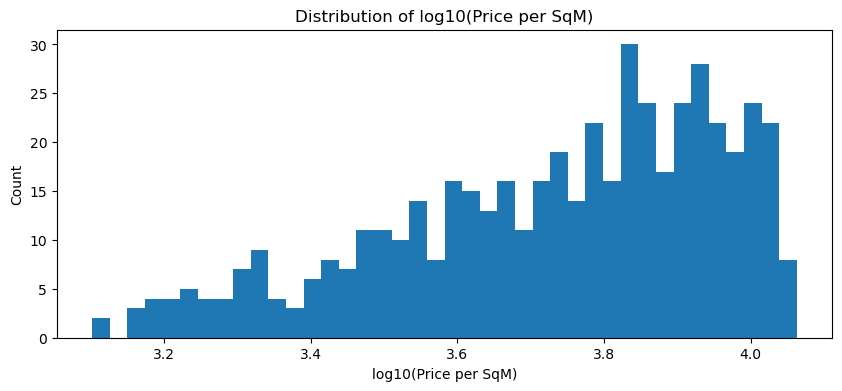

In [12]:
# Price per sqm distributions
plt.figure(figsize=(10, 4))
plt.hist(df["price_per_sqm"], bins=40)
plt.title("Distribution of Price per SqM")
plt.xlabel("Price per SqM")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df["log_price_per_sqm"], bins=40)
plt.title("Distribution of log10(Price per SqM)")
plt.xlabel("log10(Price per SqM)")
plt.ylabel("Count")
plt.show()


In [13]:
# 6) Market comparison by country
country_ppsqm = (
    df.groupby(COL_COUNTRY)["price_per_sqm"]
      .agg(mean="mean", median="median", count="count")
      .sort_values("mean", ascending=False)
)

country_price = (
    df.groupby(COL_COUNTRY)[COL_PRICE]
      .agg(mean="mean", median="median", count="count")
      .sort_values("mean", ascending=False)
)

country_ppsqm.head(10)


,mean,median,count
country,,,
Japan,6813.138772,6962.078718,30
France,6614.698762,6762.964525,27
UK,6586.268134,7237.258732,27
Canada,6430.600349,6691.090190,29
Spain,6406.613701,6428.324212,28
Germany,6359.525605,5783.222611,33
Australia,6273.222696,6095.996798,50
South Korea,6219.511054,6286.892249,38
Brazil,6019.848898,6423.107620,40


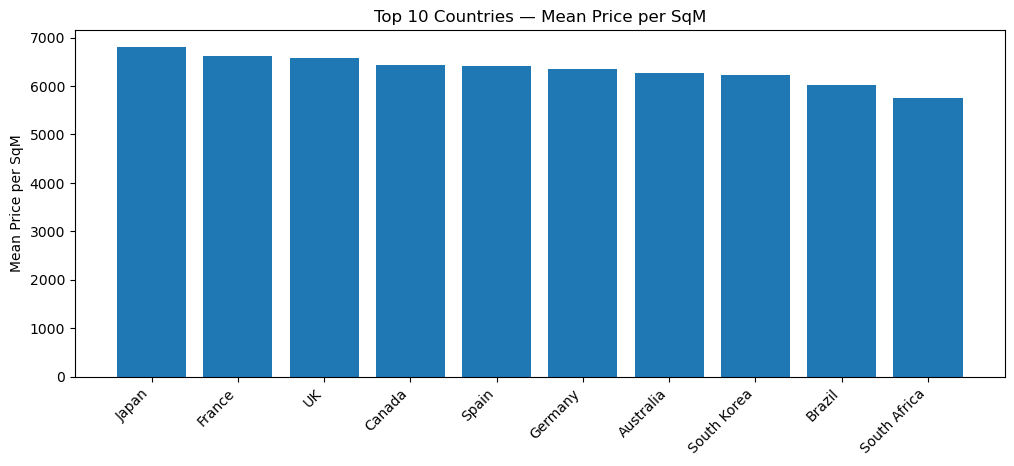

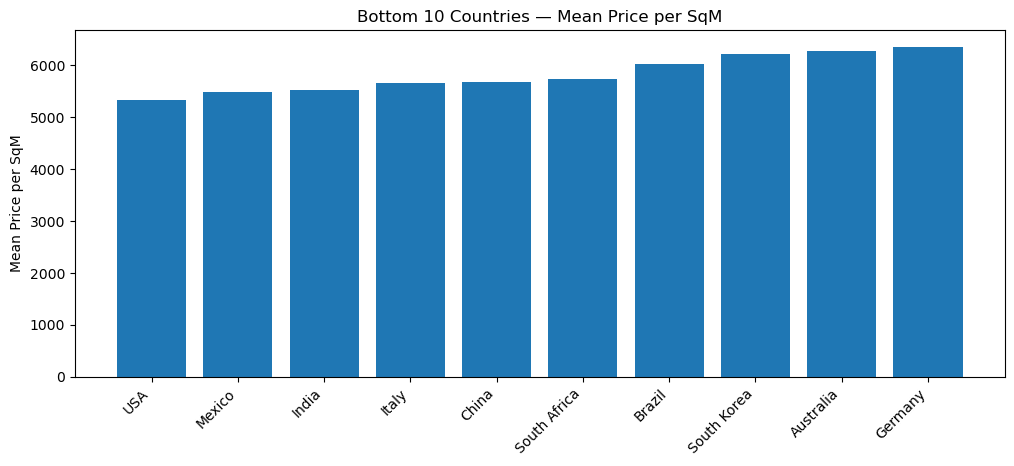

In [14]:
# Visual: Top 10 countries by mean price per sqm
top10 = country_ppsqm.head(10)

plt.figure(figsize=(12, 4.5))
plt.bar(top10.index, top10["mean"])
plt.title("Top 10 Countries — Mean Price per SqM")
plt.ylabel("Mean Price per SqM")
plt.xticks(rotation=45, ha="right")
plt.show()

# Visual: Bottom 10
bottom10 = country_ppsqm.tail(10).sort_values("mean", ascending=True)
plt.figure(figsize=(12, 4.5))
plt.bar(bottom10.index, bottom10["mean"])
plt.title("Bottom 10 Countries — Mean Price per SqM")
plt.ylabel("Mean Price per SqM")
plt.xticks(rotation=45, ha="right")
plt.show()


/var/folders/p1/6s3z304j6rl964knc01d38xm0000gn/T/ipykernel_13478/3292570659.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top_by_count, showfliers=False)


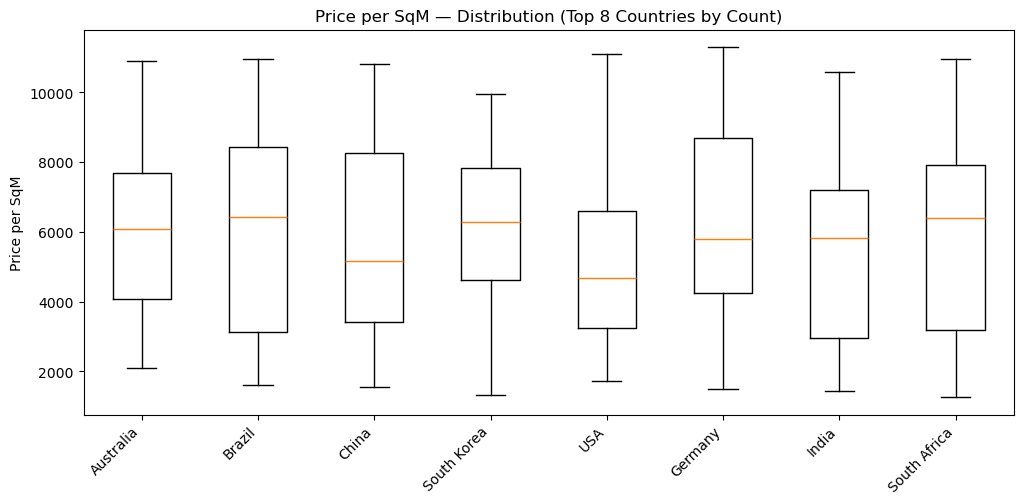

In [15]:
# Visual: Distribution of price_per_sqm by country (top 8 by count)
top_by_count = df[COL_COUNTRY].value_counts().head(8).index.tolist()
subset = df[df[COL_COUNTRY].isin(top_by_count)]

data = [subset.loc[subset[COL_COUNTRY] == c, "price_per_sqm"].values for c in top_by_count]

plt.figure(figsize=(12, 5))
plt.boxplot(data, labels=top_by_count, showfliers=False)
plt.title("Price per SqM — Distribution (Top 8 Countries by Count)")
plt.ylabel("Price per SqM")
plt.xticks(rotation=45, ha="right")
plt.show()


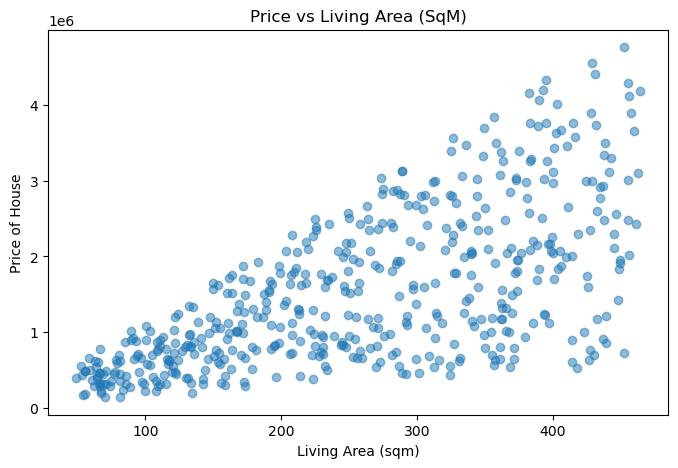

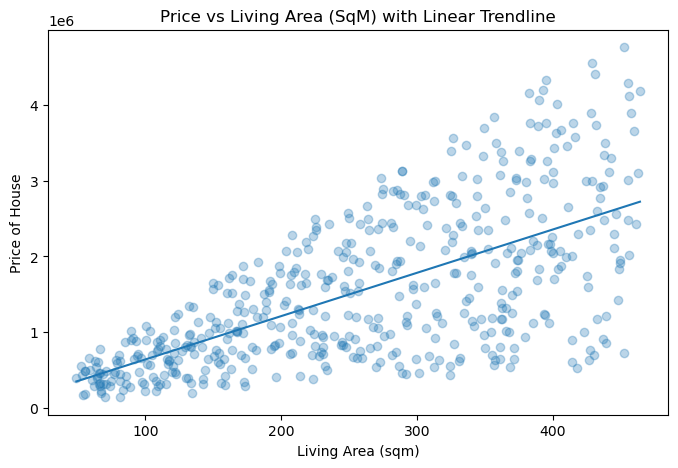

In [16]:
# 7.1 Size vs Price (scatter) + trendline
plt.figure(figsize=(8, 5))
plt.scatter(df["living_area_sqm"], df[COL_PRICE], alpha=0.5)
plt.title("Price vs Living Area (SqM)")
plt.xlabel("Living Area (sqm)")
plt.ylabel("Price of House")
plt.show()

x = df["living_area_sqm"].values
y = df[COL_PRICE].values
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.3)
plt.plot(np.sort(x), m*np.sort(x) + b)
plt.title("Price vs Living Area (SqM) with Linear Trendline")
plt.xlabel("Living Area (sqm)")
plt.ylabel("Price of House")
plt.show()


/var/folders/p1/6s3z304j6rl964knc01d38xm0000gn/T/ipykernel_13478/1012290582.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(int(c)) for c in cats], showfliers=False)


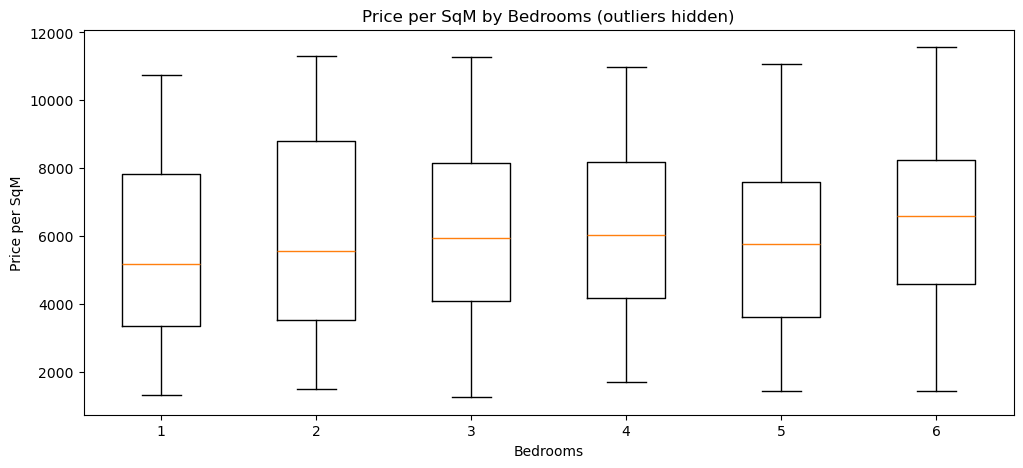

In [17]:
# 7.2 Bedrooms vs price_per_sqm (boxplot)
if COL_BEDS in df.columns:
    beds = df.dropna(subset=[COL_BEDS]).copy()
    beds = beds[(beds[COL_BEDS] >= 0) & (beds[COL_BEDS] <= 10)]
    cats = sorted(beds[COL_BEDS].dropna().unique())
    data = [beds.loc[beds[COL_BEDS] == c, "price_per_sqm"].values for c in cats]

    plt.figure(figsize=(12, 5))
    plt.boxplot(data, labels=[str(int(c)) for c in cats], showfliers=False)
    plt.title("Price per SqM by Bedrooms (outliers hidden)")
    plt.xlabel("Bedrooms")
    plt.ylabel("Price per SqM")
    plt.show()
else:
    print("Bedrooms column not found.")


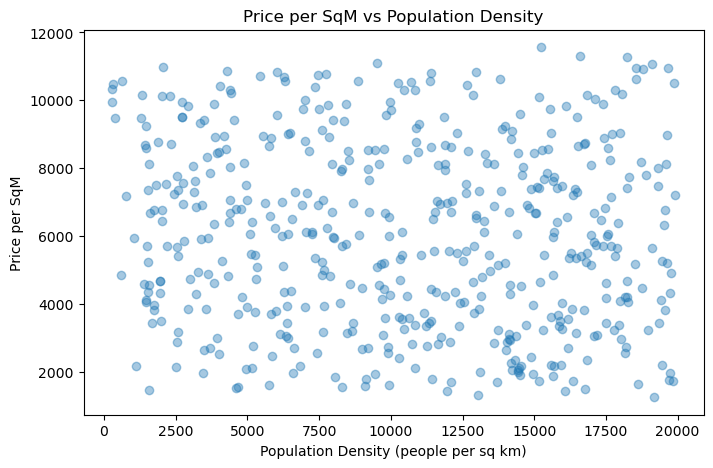

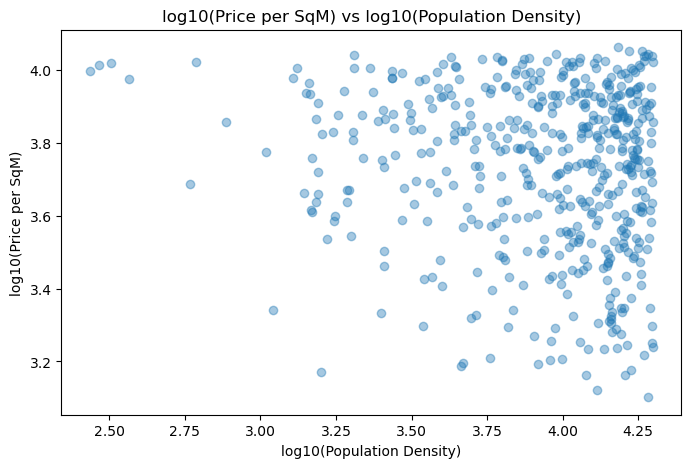

In [18]:
# 7.3 Population density vs price_per_sqm (scatter + log-log)
if COL_POPDEN in df.columns:
    dens = df.dropna(subset=[COL_POPDEN]).copy()

    plt.figure(figsize=(8, 5))
    plt.scatter(dens[COL_POPDEN], dens["price_per_sqm"], alpha=0.4)
    plt.title("Price per SqM vs Population Density")
    plt.xlabel("Population Density (people per sq km)")
    plt.ylabel("Price per SqM")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.scatter(np.log10(dens[COL_POPDEN]), np.log10(dens["price_per_sqm"]), alpha=0.4)
    plt.title("log10(Price per SqM) vs log10(Population Density)")
    plt.xlabel("log10(Population Density)")
    plt.ylabel("log10(Price per SqM)")
    plt.show()
else:
    print("Population density column not found.")


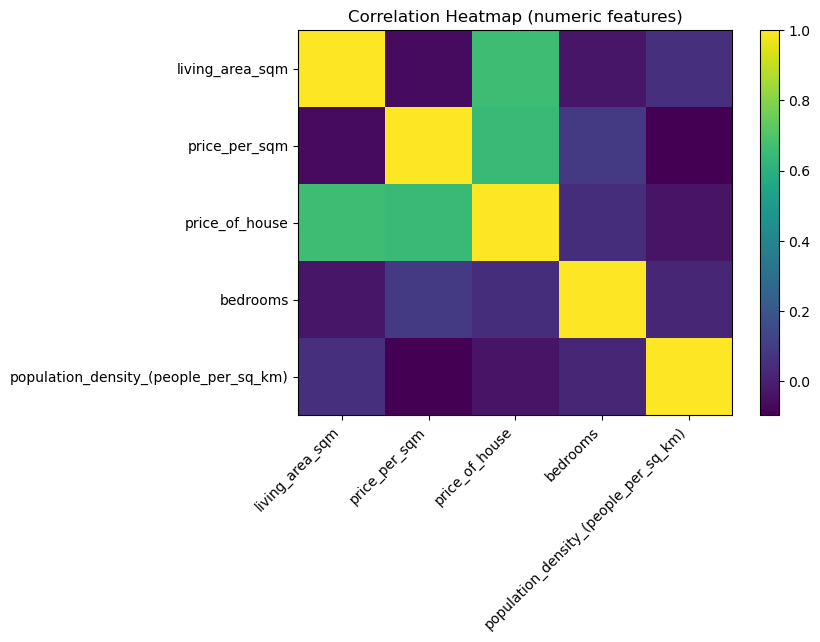

,living_area_sqm,price_per_sqm,price_of_house,bedrooms,population_density_(people_per_sq_km)
living_area_sqm,1.000000,-0.063332,0.660960,-0.030513,0.054406
price_per_sqm,-0.063332,1.000000,0.644462,0.087964,-0.096504
price_of_house,0.660960,0.644462,1.000000,0.047014,-0.040190
bedrooms,-0.030513,0.087964,0.047014,1.000000,0.020366
population_density_(people_per_sq_km),0.054406,-0.096504,-0.040190,0.020366,1.000000


In [19]:
# 8) Correlations (numeric)
num_cols = ["living_area_sqm", "price_per_sqm", COL_PRICE]
if COL_BEDS in df.columns: num_cols.append(COL_BEDS)
if COL_POPDEN in df.columns: num_cols.append(COL_POPDEN)

corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap (numeric features)")
plt.colorbar()
plt.show()

corr


In [20]:
# 9) Optional: Outlier review (99th percentile caps)
p99_price = df[COL_PRICE].quantile(0.99)
p99_ppsqm = df["price_per_sqm"].quantile(0.99)

df_capped = df.copy()
df_capped[COL_PRICE] = np.minimum(df_capped[COL_PRICE], p99_price)
df_capped["price_per_sqm"] = np.minimum(df_capped["price_per_sqm"], p99_ppsqm)

print("Original mean price_per_sqm:", df["price_per_sqm"].mean())
print("Capped   mean price_per_sqm:", df_capped["price_per_sqm"].mean())

orig = df.groupby(COL_COUNTRY)["price_per_sqm"].mean().sort_values(ascending=False).head(10)
cap  = df_capped.groupby(COL_COUNTRY)["price_per_sqm"].mean().sort_values(ascending=False).head(10)

comparison = pd.DataFrame({"orig_mean_ppsqm": orig, "capped_mean_ppsqm": cap})
comparison


Original mean price_per_sqm: 6060.236088822573
Capped   mean price_per_sqm: 6057.524518206863


,orig_mean_ppsqm,capped_mean_ppsqm
country,,
Japan,6813.138772,6793.906238
France,6614.698762,6614.698762
UK,6586.268134,6586.268134
Canada,6430.600349,6430.600349
Spain,6406.613701,6406.613701
Germany,6359.525605,6341.750383
Australia,6273.222696,6273.222696
South Korea,6219.511054,6219.511054
Brazil,6019.848898,6019.848898


In [21]:
# 10) Conclusion helper outputs
overall = {
    "n_rows": int(df.shape[0]),
    "n_countries": int(df[COL_COUNTRY].nunique()),
    "mean_price": float(df[COL_PRICE].mean()),
    "median_price": float(df[COL_PRICE].median()),
    "mean_ppsqm": float(df["price_per_sqm"].mean()),
    "median_ppsqm": float(df["price_per_sqm"].median()),
    "corr_price_area": float(df[[COL_PRICE, "living_area_sqm"]].corr().iloc[0,1]),
}

top_ppsqm = df.groupby(COL_COUNTRY)["price_per_sqm"].mean().sort_values(ascending=False).head(5)
bottom_ppsqm = df.groupby(COL_COUNTRY)["price_per_sqm"].mean().sort_values(ascending=True).head(5)

overall, top_ppsqm, bottom_ppsqm


({'n_rows': 500,
  'n_countries': 15,
  'mean_price': 1534485.2998199998,
  'median_price': 1229617.155,
  'mean_ppsqm': 6060.236088822573,
  'median_ppsqm': 6004.368711776013,
  'corr_price_area': 0.6609603778827521},
 country
 Japan     6813.138772
 France    6614.698762
 UK        6586.268134
 Canada    6430.600349
 Spain     6406.613701
 Name: price_per_sqm, dtype: float64,
 country
 USA       5327.968733
 Mexico    5477.325776
 India     5523.182157
 Italy     5661.320080
 China     5680.659758
 Name: price_per_sqm, dtype: float64)

## Conclusion

- This dataset contains **500 listings across 15 countries** with property size (SqFt), bedrooms, population density, and total house price.
- After converting **SqFt → SqM**, the **mean price per sqm** across all listings is approximately **6.06k**, with a **median around 6.00k**, suggesting moderate skew/outliers.
- Based on **mean price per sqm**, the most expensive markets in this sample are led by **Japan, France, the UK, Canada, and Spain**.  
  **South Africa** sits at about **5.74k per sqm** (n=31), i.e., *~5.7k per sqm — not “5700k” as a total price*.
- **Living area is the strongest driver of total price** (correlation ≈ **0.66**), while **bedrooms** and **population density** show weaker relationships with price per sqm in this dataset.
- For more reliable cross-country comparison and modelling, next steps should include confirming **currency consistency**, adding richer property attributes (type, age/condition, amenities), and using **robust metrics** (medians / capped means) to reduce outlier impact.
